# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/demo/DAY_1_DEMO_SESSION_4_hierarchical_agent_teams.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# About this notebook

This notebook builds a hierarchical, team based agent system with **LangGraph** and **LangChain** that can research on the web, scrape pages, search patents, run code, and collaborate to write and persist a report to disk. It demonstrates how to compose multiple subgraphs under a top level supervisor while keeping tools, roles, and state explicit.

## What it shows

* **Two specialized teams** coordinated by supervisors

  1. **Research team** with search, scraping, Exa semantic search, and Google Patents
  2. **Document writing team** with outline creation, document read and write, editing, and a Python REPL for simple charts
* **Top level orchestrator** that routes work between the two teams and aggregates results
* **Tooling mix**: Tavily, SerpAPI, Exa, WebBaseLoader scraping, and a Python REPL
* **File persistence** in a working directory for outlines and the final report
* **Streaming runs** that print step by step updates and **Mermaid PNG** graph previews for each team and the supervisor graph

## What you will run

1. . Define research tools

   * `tavily_tool` for search results
   * `scrape_webpages` to pull and concatenate page contents
   * `patent_search` via SerpAPI Google Patents
   * `exa_search_tool` for neural search with highlight snippets
2. Define document tools

   * `create_outline`, `read_document`, `write_document`, `edit_document` that operate in a sandboxed working directory
   * `python_repl_tool` for quick calculations or charts printed to stdout
3. Build **worker nodes** using `create_react_agent` and **LLM supervisors** with structured routing that pick the next worker or finish.
4. Compile three graphs

   * `research_graph` for web research and patents
   * `paper_writing_graph` for outlining and writing with optional chart generation
   * `super_graph` that orchestrates both teams end to end
5. Execute an example

   * Ask about AI agents and patents with the research team
   * Write a poem to disk with the writing team
   * Run a full task that produces an 800 word semiconductor whitepaper, includes patent links and sources, and saves it to `semiconductor_whitepaper.txt`

## How it works

* **Supervisors**: Small LLM routers with structured output select the next worker from a fixed set or return FINISH.
* **Workers**: ReAct style agents bound to a specific tool set and prompt. Each worker returns a single concise message which is fed back to the supervisor.
* **State**: Uses `MessagesState` plus a simple `next` field. Messages flow across teams so the top level supervisor can coordinate.
* **Routing**: Implemented through `Command(goto=..., update=...)` to move between nodes while appending results to state.
* **Persistence**: File tools read and write under `WORKING_DIRECTORY`. The final task writes a complete report to disk.

## Why this pattern

* Clear separation of concerns makes behaviors predictable and testable.
* Supervisors keep control flow explicit and auditable.
* Tool use is bounded per worker which reduces prompt sprawl and improves reliability.
* The top level graph composes teams without coupling their internal details.

## Extend and adapt

* Add a citation validator between research and writing.
* Swap or add search providers.
* Replace Python REPL with a sandboxed executor.
* Persist checkpoints and traces with LangSmith for debugging and evaluation.

## Requirements and notes

* Required keys: `OPENAI_API_KEY`, `TAVILY_API_KEY`, `SERPAPI_API_KEY`, `EXA_API_KEY`.
* Web results and patent listings change over time. Outputs will vary run to run.
* File system tools write to the working directory. Use a sandbox for untrusted content or use it within a Docker setup.
* Streaming prints intermediate updates that help you trace decisions and tool calls.


# Dependencies

In [ ]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    langchain_community==0.3.30 \
    langchain-tavily==0.2.11 \
    exa_py==1.15.6 \
    python-dotenv==1.1.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 

# API Key Setup

In [ ]:
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
# TAVILY_API_KEY=your_tavily_key_here
# SERPAPI_API_KEY=your_serpapi_key_here
# EXA_API_KEY=your_exa_key_here
#
# Option 2: set directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here
# %env TAVILY_API_KEY=your_tavily_key_here
# %env SERPAPI_API_KEY=your_serpapi_key_here
# %env EXA_API_KEY=your_exa_key_here

from dotenv import load_dotenv
import os

# Load from .env if available
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
SERPAPI_API_KEY = os.getenv("SERPAPI_API_KEY")
EXA_API_KEY = os.getenv("EXA_API_KEY")

# Fallback: ask if still missing
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not TAVILY_API_KEY:
    print("⚠️ TAVILY_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    TAVILY_API_KEY = input("Enter your TAVILY_API_KEY: ").strip()

if not SERPAPI_API_KEY:
    print("⚠️ SERPAPI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    SERPAPI_API_KEY = input("Enter your SERPAPI_API_KEY: ").strip()

if not EXA_API_KEY:
    print("⚠️ EXA_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    EXA_API_KEY = input("Enter your EXA_API_KEY: ").strip()

print("✅ API keys loaded successfully!")


✅ API keys loaded successfully!


<div class="admonition tip">
    <p class="admonition-title">Set up <a href="https://smith.langchain.com">LangSmith</a> for LangGraph development</p>
    <p style="padding-top: 5px;">
        Sign up for LangSmith to quickly spot issues and improve the performance of your LangGraph projects. LangSmith lets you use trace data to debug, test, and monitor your LLM apps built with LangGraph — read more about how to get started <a href="https://docs.smith.langchain.com">here</a>.
    </p>
</div>

# Imports

In [ ]:
from __future__ import annotations

# Stdlib
import json
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Any, Annotated, Dict, List, Literal, Optional, Sequence
from typing_extensions import TypedDict

# Third party
from exa_py import Exa
from langchain_openai import ChatOpenAI

# LangChain
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import BaseMessage, HumanMessage, trim_messages
from langchain_core.tools import tool

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import SerpAPIWrapper

from langchain_experimental.utilities import PythonREPL

from langchain_tavily import TavilySearch

# LangGraph
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command


# Create Tools

Each team will be composed of one or more agents each with one or more tools. Below, define all the tools to be used by your different teams.

We'll start with the research team.

**ResearchTeam tools**

The research team can use a search engine and url scraper to find information on the web. Feel free to add additional functionality below to boost the team performance!

**Document writing team tools**

Next up, we will give some tools for the doc writing team to use.
We define some bare-bones file-access tools below.

Note that this gives the agents access to your file-system, which can be unsafe. We also haven't optimized the tool descriptions for performance.

In [ ]:
# Define a persistent working directory
WORKING_DIRECTORY = Path("/content/working_directory")

# Ensure the working directory exists
if not WORKING_DIRECTORY.exists():
    WORKING_DIRECTORY.mkdir(parents=True)
    print(f"Created working directory: {WORKING_DIRECTORY}")
else:
    print(f"Working directory already exists: {WORKING_DIRECTORY}")


@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

@tool("patent_search")
def patent_search(query: str) -> str:
    """Search with Google SERP API by a query to find patents related to the query."""
    params = {
        "engine": "google_patents",
        "gl": "us",
        "hl": "en",
        }
    patent_search = SerpAPIWrapper(params=params, serpapi_api_key=SERPAPI_API_KEY)
    return patent_search.run(query)


@tool("exa_search_tool")
def exa_search_tool(question: str) -> str:
    """Tool using Exa's Python SDK to run semantic search and return result highlights."""
    exa = Exa(EXA_API_KEY)

    response = exa.search_and_contents(
        question,
        type="neural",
        use_autoprompt=True,
        num_results=3,
        highlights=True
    )

    results = []
    for idx, eachResult in enumerate(response.results):
        result = {
            "Title": eachResult.title,
            "URL": eachResult.url,
            "Highlight": "".join(eachResult.highlights)
        }
        results.append(result)

    return json.dumps(results)

# Load Tavily Search Wrapper from LangChain
tavily_tool = TavilySearchResults(
    max_results= 5,
    search_depth = "advanced"
    )

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"


# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

Created working directory: /content/working_directory


/tmp/ipykernel_267/14485079.py:61: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


# Helper Utilities

We are going to create a few utility functions to make it more concise when we want to:

1. Create a worker agent.
2. Create a supervisor for the sub-graph.

These will simplify the graph compositional code at the end for us so it's easier to see what's going on.

In [ ]:
class State(MessagesState):
    next: str


def make_supervisor_node(llm: BaseChatModel, members: list[str]):
    options = ["FINISH", *members]
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: str

    def supervisor_node(state: State) -> Command:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
            *state["messages"],
        ]
        response = llm.with_structured_output(Router).invoke(messages)
        choice = response["next"]
        if choice not in options:
            choice = "FINISH"

        goto = END if choice == "FINISH" else choice
        return Command(goto=goto, update={"next": choice})

    return supervisor_node

In [ ]:

def make_react_worker_node(
    *,
    llm: ChatOpenAI,
    name: str,
    tools: list,
    prompt: str | None = None,
    goto: str = "supervisor",
):
    agent = create_react_agent(llm, tools=tools, prompt=prompt)

    def node(state: State) -> Command:
        result: Dict[str, Any] = agent.invoke(state)
        msgs: Sequence[BaseMessage] = result.get("messages", [])
        content = getattr(msgs[-1], "content", "") if msgs else ""
        return Command(
            update={"messages": [HumanMessage(content=content, name=name)]},
            goto=goto,
        )

    return node


def build_team_graph(
    *,
    llm: ChatOpenAI,
    specs: list[dict[str, Any]],
    supervisor_name: str = "supervisor",
):
    member_names = [spec["name"] for spec in specs]

    builder = StateGraph(State)
    builder.add_node(
        supervisor_name,
        make_supervisor_node(llm, member_names),
        destinations=tuple([*member_names, END]),
    )

    for spec in specs:
        builder.add_node(
            spec["name"],
            make_react_worker_node(llm=llm, goto=supervisor_name, **spec),
            destinations=(supervisor_name,),
        )

    builder.add_edge(START, supervisor_name)
    return builder.compile()


## Define Agent Teams

Now we can get to define our hierarchical teams. "Choose your player!"

### Research Team

The research team will have a search agent and a web scraping "research_agent" as the two worker nodes. Let's create those, as well as the team supervisor.

Now that we've created the necessary components, defining their interactions is easy. Add the nodes to the team graph, and define the edges, which determine the transition criteria.

## LLM Setup

In [ ]:
llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

In [ ]:
# Prompts help to keep roles sharp
SEARCH_PROMPT = """Role: Web researcher. Use the search tool and return a
concise research note with sources. No follow-up questions."""

SCRAPER_PROMPT = """Role: Web scraper. Use the scraping tool to fetch details
from given URLs and summarize key findings. No follow-up questions."""

EXA_PROMPT = """Role: Research assistant. You can search for all recent info
on Exa Search. Your response should clearly articulate the key points you found."""

PATENT_PROMPT = """Role: Market researcher with 20 years of experience.
You are very knowledgeable in patent research and in finding up-to-date info
about patents using the Google Patents API."""

research_specs = [
    dict(
        name="search",
        tools=[tavily_tool],
        prompt=SEARCH_PROMPT,
    ),
    dict(
        name="web_scraper",
        tools=[scrape_webpages],
        prompt=SCRAPER_PROMPT,
    ),
    dict(
        name="exa_search",
        tools=[exa_search_tool],
        prompt=EXA_PROMPT,
    ),
    dict(
        name="patent_research",
        tools=[patent_search],
        prompt=PATENT_PROMPT,
    ),
]


In [ ]:
research_graph = build_team_graph(llm=llm, specs=research_specs)

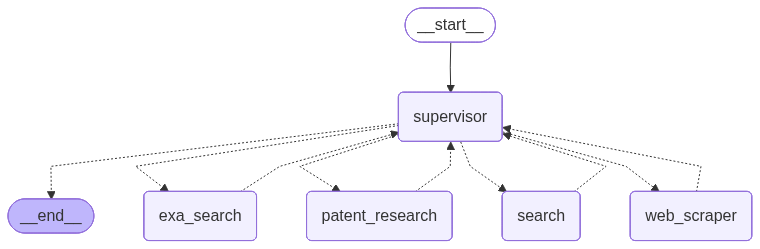

In [ ]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

We can give this team work directly. Try it out below.

In [ ]:
for s in research_graph.stream(
    {"messages": [("user", "What are AI agents? Are there any patents out there about LLM agents?")]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content='**AI agents** are AI systems that can **autonomously pursue a goal** by planning steps, using tools, and taking actions in an environment (for example: calling APIs, searching databases, running code, or interacting with software). In practice, many modern “AI agents” are built around an **LLM as the reasoning/planning core**, plus tool-use, memory, and workflow orchestration.\n\n**Short version:**  \n- **AI agent** = broader term for autonomous task-performing system.  \n- **LLM agent** = AI agent where the **large language model** is the central controller/reasoner.\n\n### Patents about LLM agents?\nYes — there are already many patent filings and grants that cover LLM-agent-style systems. Examples I found:\n\n- **Broadridge** — *Systems and methods of large language model driven orchestration of task-specific machine learning software agents* (US12061970B1 / related application)  \n- **Meta** — *Lar

### Document Writing Team

Create the document writing team below using a similar approach. This time, we will give each agent access to different file-writing tools.

Note that we are giving file-system access to our agent here, which is not safe in all cases.

With the objects themselves created, we can form the graph.

In [ ]:
paper_writing_specs = [
    dict(name="doc_writer",
         tools=[write_document, edit_document, read_document],
         prompt="You can read, write and edit documents based on note-taker's outlines. Don't ask follow-up questions."),
    dict(name="note_taker",
         tools=[create_outline, read_document],
         prompt="You can read documents and create outlines for the document writer. Don't ask follow-up questions."),
    dict(name="chart_generator",
         tools=[read_document, python_repl_tool],
         prompt=None),
]


In [ ]:
# Create the graph here
paper_writing_graph = build_team_graph(llm=llm, specs=paper_writing_specs)

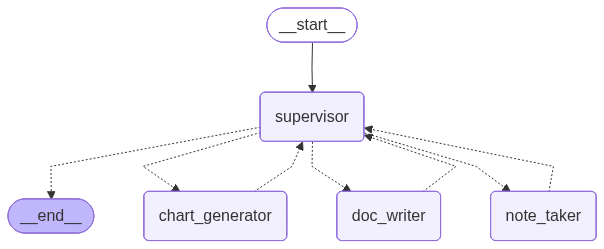

In [ ]:
from IPython.display import Image, display

display(Image(paper_writing_graph.get_graph().draw_mermaid_png()))

In [ ]:
for s in paper_writing_graph.stream(
    {
        "messages": [
            (
                "user",
                "Write an outline for poem about cats and then write the poem to disk as txt file.",
            )
        ]
    },
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'doc_writer'}}
---
{'doc_writer': {'messages': [HumanMessage(content='Done — I wrote the outline and poem to `cats_poem.txt`.', additional_kwargs={}, response_metadata={}, name='doc_writer', id='8659f6f1-2c48-44fe-ba66-bcdef7ed11c3')]}}
---
{'supervisor': {'next': 'FINISH'}}
---


## Add Layers

In this design, we are enforcing a top-down planning policy. We've created two graphs already, but we have to decide how to route work between the two.

We'll create a _third_ graph to orchestrate the previous two, and add some connectors to define how this top-level state is shared between the different graphs.

In [ ]:
from langchain_core.messages import BaseMessage

llm = ChatOpenAI(model="gpt-5.4-mini")

teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

In [ ]:
def call_research_team(state: State) -> Command:
    response = research_graph.invoke({"messages": [state["messages"][-1]]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )


def call_paper_writing_team(state: State) -> Command:
    response = paper_writing_graph.invoke({"messages": [state["messages"][-1]]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )


# Define the graph.
super_builder = StateGraph(State)
super_builder.add_node(
    "supervisor",
    teams_supervisor_node,
    destinations=("research_team", "writing_team", END),
)
super_builder.add_node(
    "research_team",
    call_research_team,
    destinations=("supervisor",),
)
super_builder.add_node(
    "writing_team",
    call_paper_writing_team,
    destinations=("supervisor",),
)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

In [ ]:
# Rebuild the top-level graph with capability-aware routing and full message history
llm = ChatOpenAI(model="gpt-4o", temperature=0)


def make_top_level_supervisor(llm: BaseChatModel):
    system_prompt = """You are the top-level supervisor coordinating two teams.

Team responsibilities:
- research_team: gather facts, recent developments, patents, and source links.
- writing_team: write, revise, and save documents to disk with the document tools.

Routing policy:
- Send work to research_team when the task needs external research, patents, or sources.
- Send work to writing_team when the task needs drafting, editing, or saving a file.
- For tasks that need both, call research_team first, then writing_team.
- Do not finish until the user's requested deliverable has been produced.
- If the user explicitly asks to save a file, writing_team must be called before FINISH.

Return exactly one of: research_team, writing_team, FINISH."""

    class Router(TypedDict):
        next: str

    def supervisor_node(state: State) -> Command:
        messages = [
            {"role": "system", "content": system_prompt},
            *state["messages"],
        ]
        response = llm.with_structured_output(Router).invoke(messages)
        choice = response["next"]
        if choice not in {"research_team", "writing_team", "FINISH"}:
            choice = "FINISH"

        goto = END if choice == "FINISH" else choice
        return Command(goto=goto, update={"next": choice})

    return supervisor_node


def call_research_team(state: State) -> Command:
    response = research_graph.invoke({"messages": state["messages"]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content="Research findings:\n\n" + response["messages"][-1].content,
                    name="research_team",
                )
            ]
        },
        goto="supervisor",
    )


def call_paper_writing_team(state: State) -> Command:
    response = paper_writing_graph.invoke({"messages": state["messages"]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content,
                    name="writing_team",
                )
            ]
        },
        goto="supervisor",
    )


teams_supervisor_node = make_top_level_supervisor(llm)

super_builder = StateGraph(State)
super_builder.add_node(
    "supervisor",
    teams_supervisor_node,
    destinations=("research_team", "writing_team", END),
)
super_builder.add_node(
    "research_team",
    call_research_team,
    destinations=("supervisor",),
)
super_builder.add_node(
    "writing_team",
    call_paper_writing_team,
    destinations=("supervisor",),
)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()


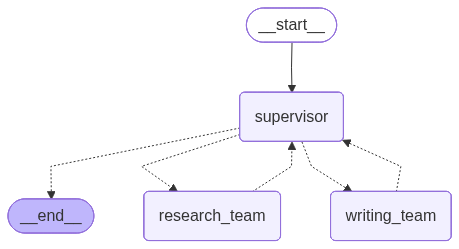

In [ ]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

In [ ]:

TASK_MSG = f"""
Write an 800-word research report white paper on ai coding agents development.
Start with an executive summary of your findings.
Search for relevant recent papers and include links to them.
IMPORTANT: Provide links to all your sources.
Finally, save the full report to disk as a .txt file using the write_document tool.

"""

# Stream the graph with the new instruction
for step in super_graph.stream(
    {
        "messages": [
            ("user", TASK_MSG.strip())
        ],
    },
    {"recursion_limit": 150},
):
    print(step)
    print("---")


{'supervisor': {'next': 'research_team'}}
---
{'research_team': {'messages': [HumanMessage(content='Research findings:\n\nI’m preparing the report, and I need to note that the requested “write_document” tool is not available in the provided toolset. I’ll still produce the report text and include source links.\n# Research Report: AI Coding Agents Development\n\n## Executive Summary\n\nAI coding agents have rapidly evolved from autocomplete tools into autonomous software engineering systems that can inspect repositories, run tests, edit files, and open pull requests. Recent research shows two major trends. First, performance has improved because agents are no longer just language models generating code; they now rely on agent-computer interfaces, tool use, and execution feedback. Second, the field is shifting from narrow benchmark solving toward real-world deployment, evaluation, and human-AI collaboration.\n\nThe strongest recurring finding is that interface and workflow design matter a

# Research Report: AI Coding Agents Development

## Executive Summary

AI coding agents have rapidly evolved from autocomplete tools into autonomous software engineering systems that can inspect repositories, run tests, edit files, and open pull requests. Recent research shows two major trends. First, performance has improved because agents are no longer just language models generating code; they now rely on agent-computer interfaces, tool use, and execution feedback. Second, the field is shifting from narrow benchmark solving toward real-world deployment, evaluation, and human-AI collaboration.

The strongest recurring finding is that interface and workflow design matter as much as model capability. Papers such as SWE-agent show that giving agents access to file navigation, shell commands, and test execution can substantially improve task success. At the same time, Agentless demonstrates that simple, interpretable pipelines can sometimes outperform more complex autonomous agents on software repair benchmarks, especially when problems are well-localized. This suggests current progress is driven by a combination of better scaffolding, better data, and better evaluation—not only larger models.

A second key finding is that evaluation is becoming more realistic. SWE-bench began as a repository-level benchmark for GitHub issues, and newer work such as SWE-bench Verified, SWE-bench Live, SWE-smith, and CodeClash reflects the community’s push toward contamination-resistant, scalable, and goal-oriented assessments. In parallel, large empirical datasets like AIDev are beginning to measure how coding agents behave in the wild across GitHub repositories.

Overall, AI coding agents are moving toward a mature software development stack: planning, retrieval, code editing, test execution, verification, and human review. The biggest open problems are reliability, cost, context management, security, and measuring usefulness in real team settings rather than only on static benchmarks.

## Main Findings

### 1. Development has shifted from code generation to agentic workflows
Early coding tools were largely completion systems. Recent coding agents now act as autonomous workers. The central architectural idea is to equip the model with a software environment and an action loop: inspect repository state, propose an edit, run commands, observe output, and iterate. SWE-agent is a key paper in this shift, arguing that the interface itself is critical for performance.

### 2. Simple pipelines can still be highly competitive
Agentless challenges the assumption that more autonomy always helps. It uses a structured localization-repair-validation workflow rather than open-ended action planning. Its results on SWE-bench Lite show that simpler methods can be cheaper and, in some cases, more effective than complex agent scaffolds. This is important for development because it pushes researchers to optimize for reliability and interpretability, not just autonomy.

### 3. Benchmarks are expanding beyond static test sets
SWE-bench established the standard task: fix real-world GitHub issues. But static benchmarks have limits, including leakage, stale tasks, and overfitting risk. SWE-bench Verified improved task quality, SWE-bench Live adds continuously updated issues, and SWE-smith focuses on scalable data generation. CodeClash goes further by evaluating goal-oriented software engineering in competitive settings rather than binary patch correctness.

### 4. Data and context are becoming first-class research objects
AIDev provides large-scale evidence that autonomous coding agents are already active in real repositories. At the same time, newer studies of context files like AGENTS.md, CLAUDE.md, and copilot-instructions.md suggest that repository instructions can strongly affect agent behavior, sometimes in unexpected ways. This means future development work will not just optimize models, but also the documentation and context environment in which agents operate.

### 5. Human-AI collaboration remains under-studied
Most coding-agent research optimizes for autonomous task completion. But real software engineering involves code review, communication, debugging, and coordination. Emerging research argues that human factors are missing from current evaluation. This is likely the next major frontier: measuring how agents assist teams, reduce cycle time, and affect code quality over weeks or months.

## Technical Implications

For developers building AI coding agents, the current research suggests five priorities:

1. **Strong agent-computer interfaces**: file search, code editing, terminal access, and test execution.
2. **Reliable verification loops**: unit tests, reproduction scripts, static checks, and patch selection.
3. **Scalable training data**: repository-level tasks and realistic trajectories.
4. **Robust evaluation**: benchmarks that resist leakage and reflect live development.
5. **Human-centered design**: visibility, controllability, and reviewability.

The design tradeoff is clear: more autonomy can improve throughput, but it also increases failure risk, tool complexity, and cost. The best systems increasingly combine bounded autonomy with strong verification.

## Conclusion

AI coding agents are developing from assistant-style tools into autonomous collaborators. The research frontier is no longer just “can the model write code?” but “can the system reliably operate inside real software workflows?” Recent papers show that success depends on interfaces, tool use, evaluation design, and data quality. The most promising path forward appears to be a hybrid one: capable agents with carefully constrained action spaces, strong test feedback, and human oversight.

## Sources and Links

1. **SWE-agent: Agent-Computer Interfaces Enable Automated Software Engineering**  
   arXiv: https://arxiv.org/abs/2405.15793  
   PDF / NeurIPS version: https://proceedings.neurips.cc/paper_files/paper/2024/file/5a7c947568c1b1328ccc5230172e1e7c-Paper-Conference.pdf

2. **Agentless: Demystifying LLM-based Software Engineering Agents**  
   arXiv: https://arxiv.org/abs/2407.01489  
   HTML: https://arxiv.org/html/2407.01489v2  
   Paper page: https://sorendunn.github.io/publication/Agentless

3. **SWE-bench: Can Language Models Resolve Real-World GitHub Issues?**  
   arXiv: https://arxiv.org/abs/2310.06770

4. **SWE-bench Live!**  
   arXiv: https://arxiv.org/abs/2505.23419

5. **SWE-smith: Scaling Data for Software Engineering Agents**  
   arXiv PDF: https://arxiv.org/pdf/2504.21798  
   Hugging Face summary: https://huggingface.co/papers/2504.21798

6. **CodeClash: Benchmarking Goal-Oriented Software Engineering**  
   arXiv HTML: https://arxiv.org/html/2511.00839v1  
   Documentation: https://docs.codeclash.ai

7. **The Rise of AI Teammates in Software Engineering (SE) 3.0**  
   arXiv HTML: https://arxiv.org/html/2507.15003v1  
   ADS abstract: https://ui.adsabs.harvard.edu/abs/2025arXiv250715003L/abstract

8. **AIDev: Studying AI Coding Agents on GitHub**  
   arXiv HTML: https://arxiv.org/html/2602.09185

9. **Agentic Much? Adoption of Coding Agents on GitHub**  
   arXiv HTML: https://arxiv.org/html/2601.18341v1

10. **Position: Humans are Missing from AI Coding Agent Research**  
   PDF: https://zorazrw.github.io/files/position-haicode.pdf
